In [1]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.9 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


PRO TIP 💡 Replace 'model=yolov5s.pt' with new 'model=yolov5su.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.


image 1/1 /content/drive/MyDrive/Deep Learning and Artificial Neural Networks/Exercise 10/samples/dog.jpg: 544x640 1 dog, 3 bottles, 6 bowls, 2 broccolis, 5 carrots, 1 potted plant, 1 oven, 1 sink, 1933.2ms
Speed: 27.9ms preprocess, 1933.2ms inference, 55.7ms postprocess per image at shape (1, 3, 544, 640)


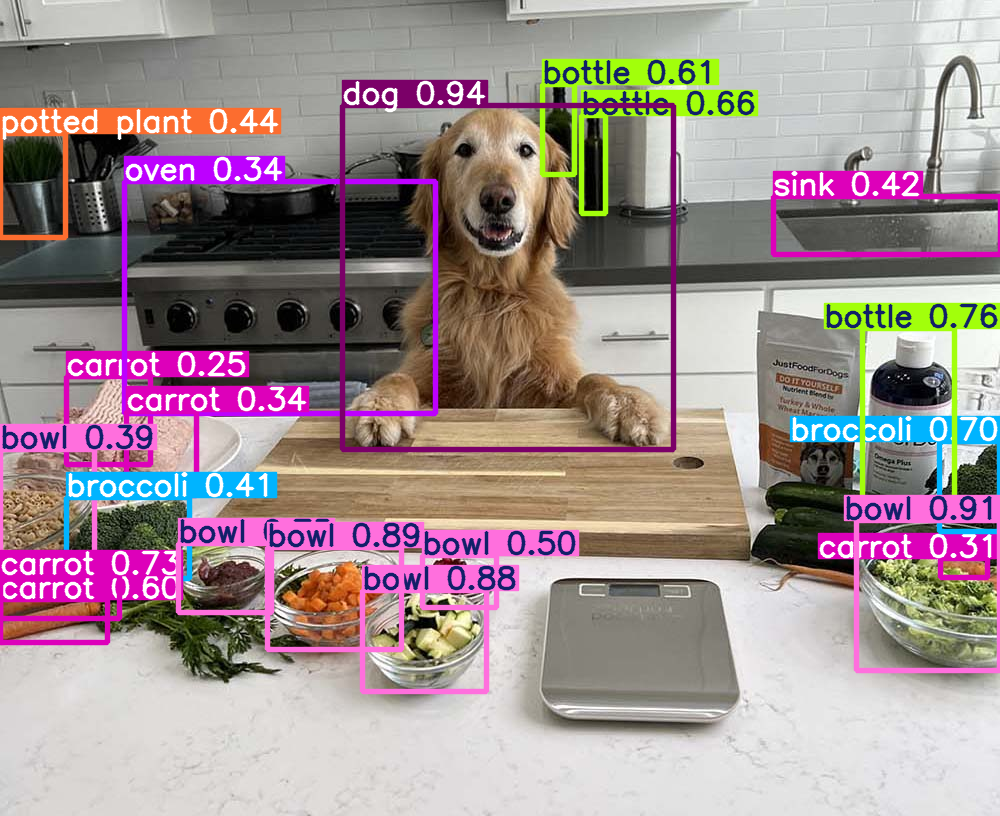

In [3]:
model = YOLO('yolov5s.pt')

img = '/content/drive/MyDrive/Deep Learning and Artificial Neural Networks/Exercise 10/samples/dog.jpg'

results = model(img)[0]

results.show()

In [4]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import collections
import re

In [5]:
raw_data, info = tfds.load("imdb_reviews", split="train", as_supervised=True, with_info=True)
print(info.description[:300])

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.YK1UM4_1.0.0/imdb_reviews-train.tfrecor…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.YK1UM4_1.0.0/imdb_reviews-test.tfrecord…

Generating unsupervised examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/imdb_reviews/plain_text/incomplete.YK1UM4_1.0.0/imdb_reviews-unsupervised.…

Dataset imdb_reviews downloaded and prepared to /root/tensorflow_datasets/imdb_reviews/plain_text/1.0.0. Subsequent calls will reuse this data.
Large Movie Review Dataset. This is a dataset for binary sentiment
classification containing substantially more data than previous benchmark
datasets. We provide a set of 25,000 highly polar movie reviews for training,
and 25,000 for testing. There is additional unlabeled data for use as well.


In [6]:
# look at one review
for text, label in raw_data.take(1):
  print("LABEL: ", label.numpy(), " (1 = positive, 0 = negative)")
  print("REVIEW: ")
  print(text.numpy().decode("utf-8")[:500], "...")

LABEL:  0  (1 = positive, 0 = negative)
REVIEW: 
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but ...


Word2Vec

Tokenization

In [7]:
# take the first 5000 reviews, and tokenize each of them separately
N_REVIEWS = 5000

reviews_tokens = []

for text, _ in raw_data.take(N_REVIEWS):
  s = text.numpy().decode("utf-8").lower() # lowered ALL letters
  reviews_tokens.append(s.split()) # basic split on whitespace

print(f'Number of reviews: {len(reviews_tokens)}')
print(f'First review (first 15 tokens): {reviews_tokens[0][:15]}') # taking the first review from the dataset [0], and first 15 tokens (words) [:15]

Number of reviews: 5000
First review (first 15 tokens): ['this', 'was', 'an', 'absolutely', 'terrible', 'movie.', "don't", 'be', 'lured', 'in', 'by', 'christopher', 'walken', 'or', 'michael']


Cleaning

In [8]:
import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

In [9]:
stop_words = set(stopwords.words("english"))
print(f"{len(stop_words)} English stopwords loaded. Examples: ", list(stop_words)[:10])

198 English stopwords loaded. Examples:  ['most', 'then', 'her', 'their', 'what', 'and', 'here', 'when', 'does', 'had']


Erasing:


Punctuation / special characters / numbers
Stop words (only if they are in stop_words)
It does not remove random short tokens like "br" unless "br" is explicitly included in stop_words.

| Original     | After cleaning |
| ------------ | -------------- |
| `"movie!"`   | `"movie"`      |
| `"great123"` | `"great"`      |
| `"<br />"`   | `"br"`         |


In [10]:
def clean(tokens):
  out = []

  for w in tokens:
    w = re.sub(r"[^a-z]", "", w) # regular expression - ^ not -> everything that is NOT a small case letter a-z, replace (sub) with "" empty string in w
    if w and w not in stop_words:
      out.append(w)

  return out

In [11]:
reviews_clean = [clean(toks) for toks in reviews_tokens]

In [12]:
print("Before: ", reviews_tokens[0][:20])
print("After: ", reviews_clean[0][:20])

Before:  ['this', 'was', 'an', 'absolutely', 'terrible', 'movie.', "don't", 'be', 'lured', 'in', 'by', 'christopher', 'walken', 'or', 'michael', 'ironside.', 'both', 'are', 'great', 'actors,']
After:  ['absolutely', 'terrible', 'movie', 'dont', 'lured', 'christopher', 'walken', 'michael', 'ironside', 'great', 'actors', 'must', 'simply', 'worst', 'role', 'history', 'even', 'great', 'acting', 'could']


Build vocabulary

In [13]:
VOCAB_SIZE = 10_000

#all_tokens = [w for review in reviews_clean for w in review]

all_tokens = []

for review in reviews_clean: # each review (a list of words)
  for w in review: # each word in that review
    all_tokens.append(w) # append the word

# reviews_clean has a shape like [ ["movie", "great", "acting"], ["worst", "film", "ever"], ...] # list of lists
# all_tokens is shaped like ["movie", "great", "acting", "worst", "film", "ever"...] # one flat list

In [14]:
print(f'Total tokens: {len(all_tokens):,}')
print(f"Unique tokens: {len(set(all_tokens)):,}")

Total tokens: 612,914
Unique tokens: 49,816


In [15]:
counter = collections.Counter(all_tokens)

print("10 most common ones: ", counter.most_common(10))

10 most common ones:  [('br', 11717), ('movie', 8291), ('film', 7449), ('one', 5142), ('like', 3968), ('good', 2905), ('even', 2424), ('would', 2407), ('time', 2382), ('really', 2331)]


In [16]:
vocab = ["UNK"] + [w for w, _ in counter.most_common(VOCAB_SIZE - 1)]

WORD -> INDEX lookup dictionary

In [17]:
word2idx = {w: i for i, w in enumerate(vocab)}
# {"UNK": 0, "movie": 1, "film": 2, "one": 3...}

INDEX -> WORD reverse lookup dictionary

In [18]:
idx2word = {i: w for w, i in word2idx.items()}

In [19]:
print(f"vocabulary size: {len(vocab)}")
print(f"word2idx['movie'] = {word2idx.get("movie")}")
print(f"idx2word[1] = {idx2word[1]!r}")

vocabulary size: 10000
word2idx['movie'] = 2
idx2word[1] = 'br'


| Step                    | Direction needed           | Why                                                                                                                                                                 |
| ----------------------- | -------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Encoding text → numbers | `word2idx` (word → index)  | The neural network only accepts integers as input. When we read the word `"movie"` from a review, we need to turn it into `1`.                                      |
| Training the model      | Neither — pure number land | At this stage everything is integers and floats. The model never sees a string.                                                                                     |
| Inference / inspection  | `idx2word` (index → word)  | The model's outputs and the embedding matrix are indexed by integer. When we want to show humans what those integers mean, we need to turn `1` back into `"movie"`. |


## Encoding

In [20]:
def encode(tokens):
  out = []

  for w in tokens:
    out.append(word2idx.get(w, 0))

  return out

In [21]:
reviews_encoded = [encode(r) for r in reviews_clean] # apply the encoder to every cleaned review, outer shape stays the same (5000 reviews), inner type changes: strings -> ints

In [22]:
# sanity check
print("Original tokens: ", reviews_clean[0][:10])
print("As indices: ", reviews_encoded[0][:10])

Original tokens:  ['absolutely', 'terrible', 'movie', 'dont', 'lured', 'christopher', 'walken', 'michael', 'ironside', 'great']
As indices:  [320, 280, 2, 21, 7967, 1096, 3020, 411, 0, 19]


## Sentiment Classification

In [23]:
y_train_raw = []

for text, label in raw_data.take(N_REVIEWS):
  y_train_raw.append(int(label.numpy()))

y_train_raw = np.array(y_train_raw)

In [24]:
# sanity check
print(f"Number of labels: {len(y_train_raw)}")
print(f"Class balance: {y_train_raw.mean():.1%} positive")

Number of labels: 5000
Class balance: 50.5% positive


## Padding the sequences to the same length

In [25]:
import matplotlib.pyplot as plt

In [26]:
lenghts = [len(r) for r in reviews_encoded] # for each review r, store len(r), lenght of every encoded review (n of tokens after cleaning)

In [28]:
# pick key statistics so we can pick a sensible MAX_LEN
print(f"Min: {min(lenghts)}, Median: {int(np.median(lenghts))}, Mean: {int(np.mean(lenghts))}, 95th prct: {int(np.percentile(lenghts, 95))}, Max: {max(lenghts)}")

Min: 11, Median: 91, Mean: 122, 95th prct: 319, Max: 1440


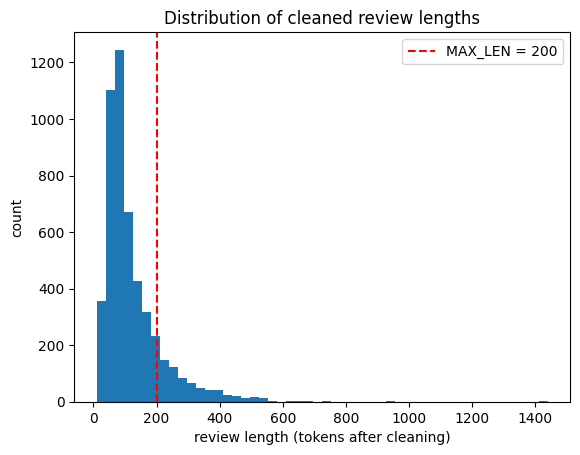

In [33]:
plt.hist(lenghts, bins=50)
plt.xlabel("review length (tokens after cleaning)")
plt.ylabel('count')

plt.axvline(200, color='red', linestyle='--', label='MAX_LEN = 200')

plt.legend()
plt.title("Distribution of cleaned review lengths")

plt.show()

In [34]:
MAX_LEN = 200

In [36]:
X_train = tf.keras.preprocessing.sequence.pad_sequences(
    reviews_encoded, # the list of int lists, one per review
    maxlen=MAX_LEN, # every output row will have exactly 200 columns
    padding='post', # adding zeros at the end of short reviews
    truncating='post' # cut off all the tail of long reviews
)

In [37]:
print(f"X_train shape: {X_train.shape} dtype: {X_train.dtype}")
print(f"y_train shape: {y_train_raw.shape}")

X_train shape: (5000, 200) dtype: int32
y_train shape: (5000,)


In [38]:
print(f"\nFirst review, first 30 positions: {X_train[0][:30]}")
print(f"First review, last 10 positions: {X_train[0][-10:]} <- zeroes = padding")


First review, first 30 positions: [ 320  280    2   21 7967 1096 3020  411    0   19   73  133  221  141  104  349    7   19   37   27 4753   26  590  649    2  278 8713   86 1861  350]
First review, last 10 positions: [0 0 0 0 0 0 0 0 0 0] <- zeroes = padding


## Building model

In [44]:
EMBEDDING_DIM = 128 # how many numbers per word vector

In [45]:
model = tf.keras.Sequential([

    # 1st layer - Embedding layer -> the big lookup yable that turns int word index into a 128-dim vector, trainable (gradient descent updates the rows during training),
    # this layer we will extract at the end as out 'learned word vectors'
    tf.keras.layers.Embedding(
        input_dim = VOCAB_SIZE, # how many distinct ints we might feed in (10_000)
        output_dim = EMBEDDING_DIM, # how many numbers per word vector (128)
        mask_zero = True, # tells downstream layers (pooling) to ignore positions where the input is 0 -> a 30-word review padded to 200 is averaged over 30 vectors, not 200
        name = "word_embedding"
    ),
    # output shape: (batch, 200, 128) -> 200 word vectors per review

    # 2nd layer - GlobalAveragePooling1D -> averages all word vectors along the sequence axis
    # input (batch, 200, 128) -> output (batch, 128)
    tf.keras.layers.GlobalAveragePooling1D(),

    # a single neuron with sigmoid activation fn: outputs number in (0, 1)
    # interpretable as P(review is positive)
    tf.keras.layers.Dense(1, activation='sigmoid', name='classifier')
])

In [46]:
model.compile(
    optimizer='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

## Training

In [49]:
EPOCHS = 5
BATCH_SIZE = 64

In [52]:
history = model.fit(
    X_train, y_train_raw,
    epochs = EPOCHS,
    batch_size = BATCH_SIZE,
    validation_split = 0.1,
    verbose=1
)

Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - accuracy: 0.6978 - loss: 0.6707 - val_accuracy: 0.8220 - val_loss: 0.6363
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8678 - loss: 0.5714 - val_accuracy: 0.8280 - val_loss: 0.5356
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.8944 - loss: 0.4471 - val_accuracy: 0.8220 - val_loss: 0.4551
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 0.9107 - loss: 0.3522 - val_accuracy: 0.8300 - val_loss: 0.4080
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.9260 - loss: 0.2864 - val_accuracy: 0.8420 - val_loss: 0.3820


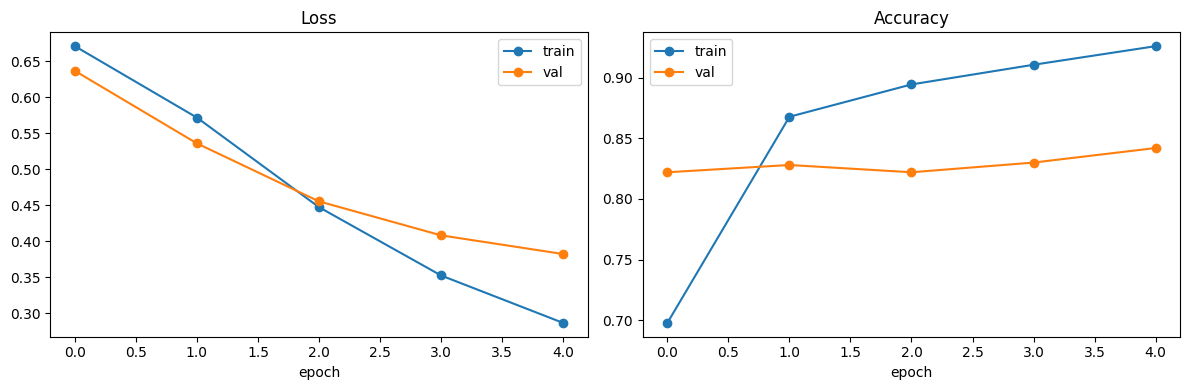

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='train', marker='o')
axes[0].plot(history.history['val_loss'], label='val', marker='o')
axes[0].set_title('Loss')
axes[0].set_xlabel('epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train', marker='o')
axes[1].plot(history.history['val_accuracy'], label='val', marker='o')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [61]:
def predict_sentiment(sentence):

  # tokenization + clean
  toks = clean(sentence.lower().split())

  # encode + pad
  enc = encode(toks)

  padded = tf.keras.preprocessing.sequence.pad_sequences(
      [enc], maxlen=MAX_LEN, padding='post', truncating='post'
  )

  # predict
  p_pos = float(model.predict(padded, verbose=0)[0,0]) # model.predict returns numpy array of shape (n_examples, 1) -> output layers has one neuron
  #[0,0] extracts the single scalar. float(...) converts numpy scalar -> python float

  label = "POSITIVE" if p_pos > 0.5 else "NEGATIVE"

  return label, p_pos, toks

In [59]:
examples = [
    "This movie was absolutely fantastic, I loved every minute of it",
    "Terrible film, boring and a complete waste of time",
    "An average film, nothing specal really",
    "It was ok, I liked the actors but terrible editting",
    "The acting was wonderful, and the story kept me engaged",
    "Worst movie I have ever seen, deeply disappointing"
]

In [63]:
for s in examples:
  label, p_pos, toks = predict_sentiment(s)
  print(f"[{label} p_pos={p_pos:.2f}] {s}")
  print(f"  tokens used: {toks}\n")

[POSITIVE p_pos=0.99] This movie was absolutely fantastic, I loved every minute of it
  tokens used: ['movie', 'absolutely', 'fantastic', 'loved', 'every', 'minute']

[NEGATIVE p_pos=0.00] Terrible film, boring and a complete waste of time
  tokens used: ['terrible', 'film', 'boring', 'complete', 'waste', 'time']

[NEGATIVE p_pos=0.00] An average film, nothing specal really
  tokens used: ['average', 'film', 'nothing', 'specal', 'really']

[NEGATIVE p_pos=0.01] It was ok, I liked the actors but terrible editting
  tokens used: ['ok', 'liked', 'actors', 'terrible', 'editting']

[POSITIVE p_pos=0.98] The acting was wonderful, and the story kept me engaged
  tokens used: ['acting', 'wonderful', 'story', 'kept', 'engaged']

[NEGATIVE p_pos=0.00] Worst movie I have ever seen, deeply disappointing
  tokens used: ['worst', 'movie', 'ever', 'seen', 'deeply', 'disappointing']

